In [11]:
from RBF_code import *

import matplotlib.pyplot as plt

plt.style.use("bmh")

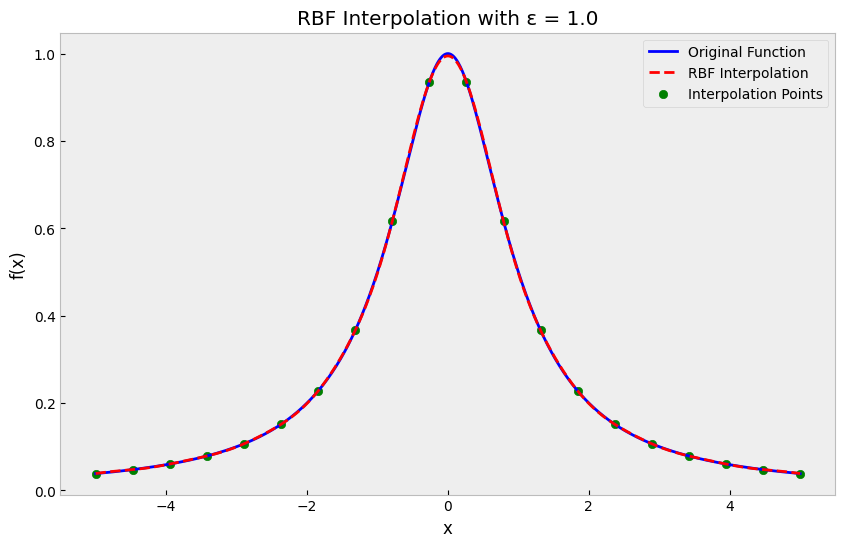

In [12]:
test = RBF(-5,5,function='runge_function',num_points=20,epsilon=1.0)
test.plot()

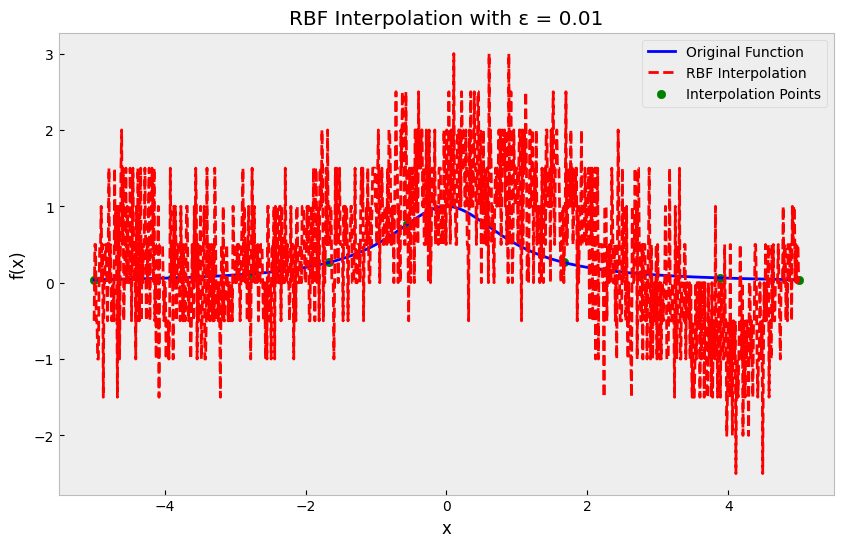

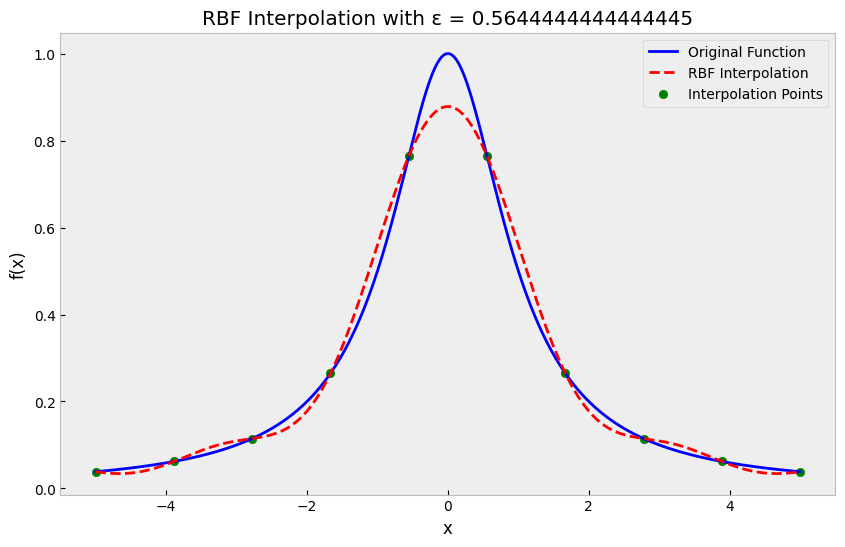

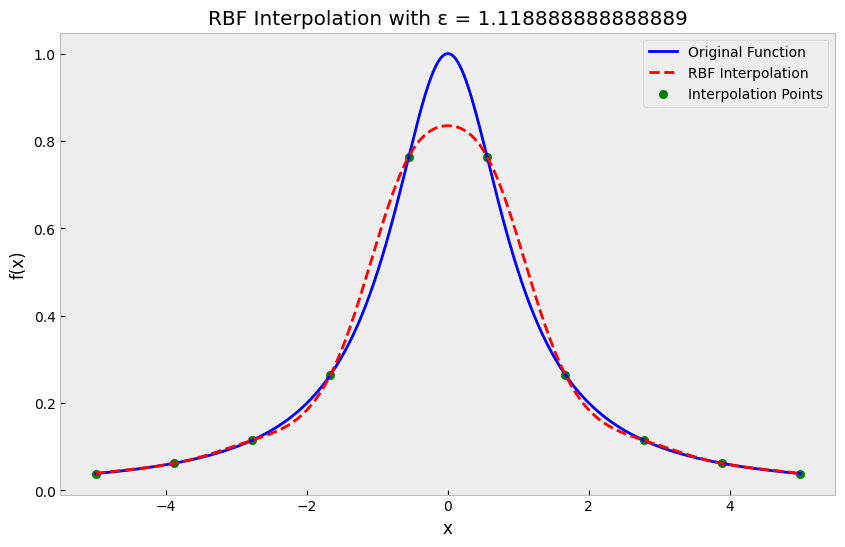

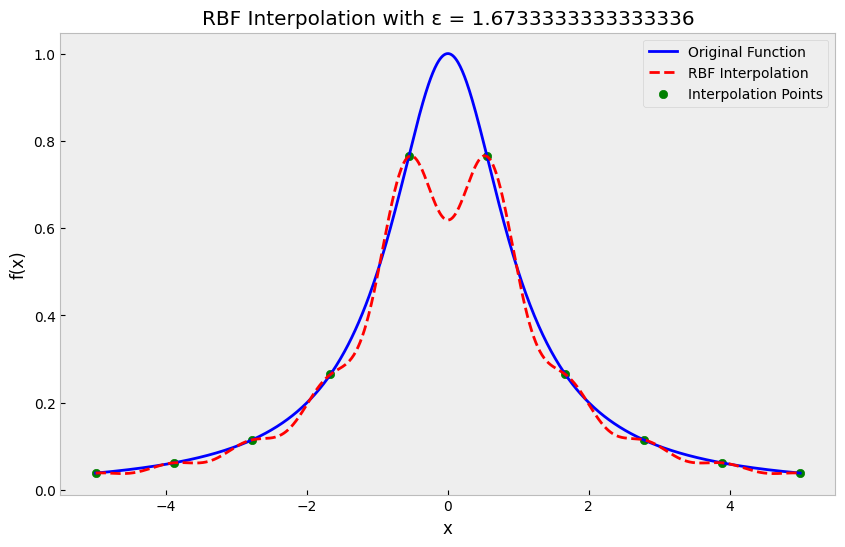

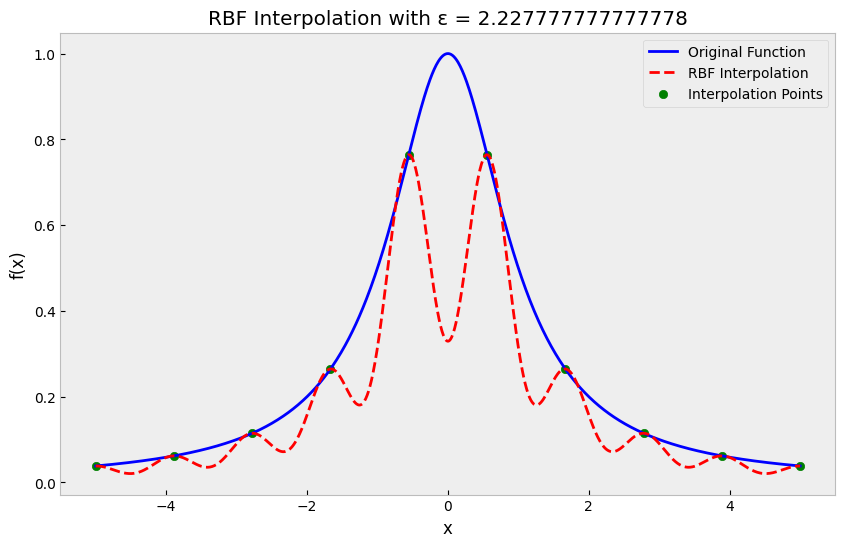

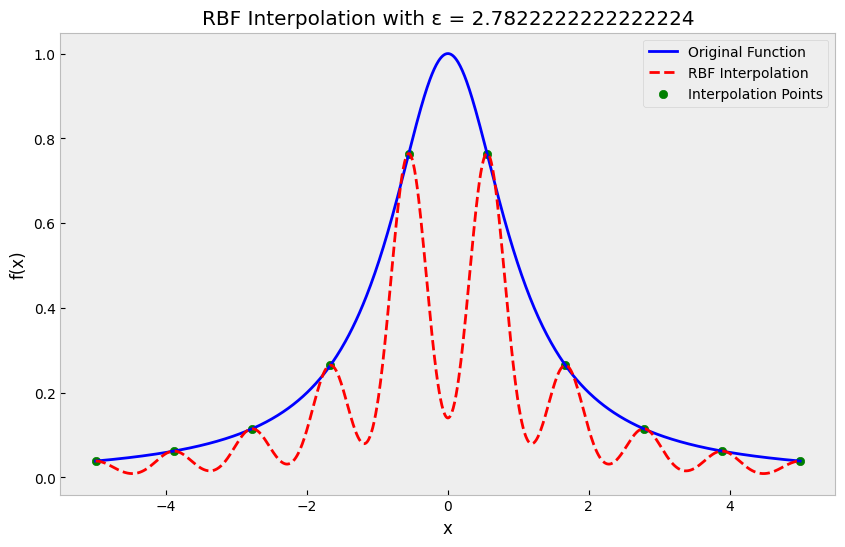

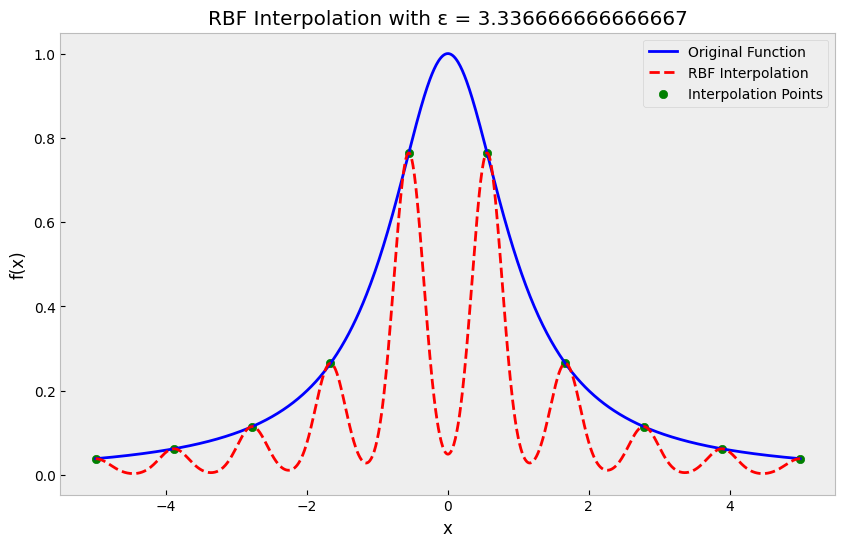

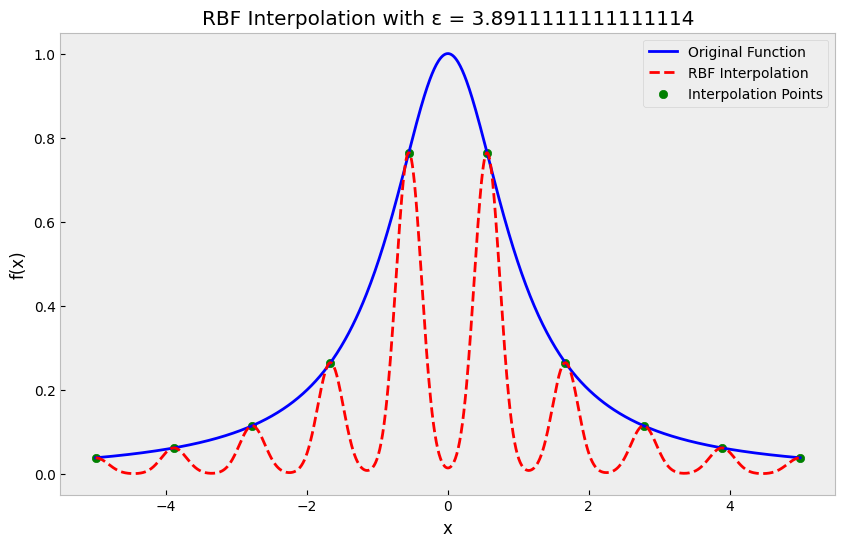

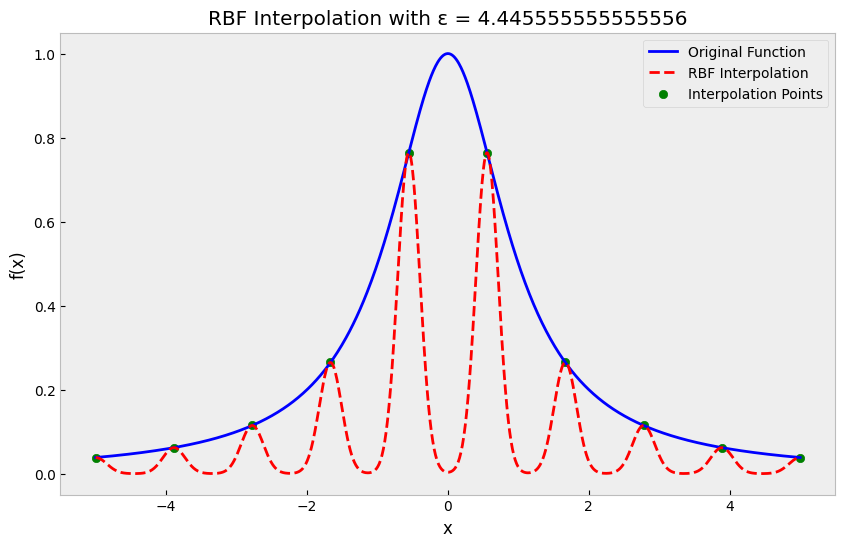

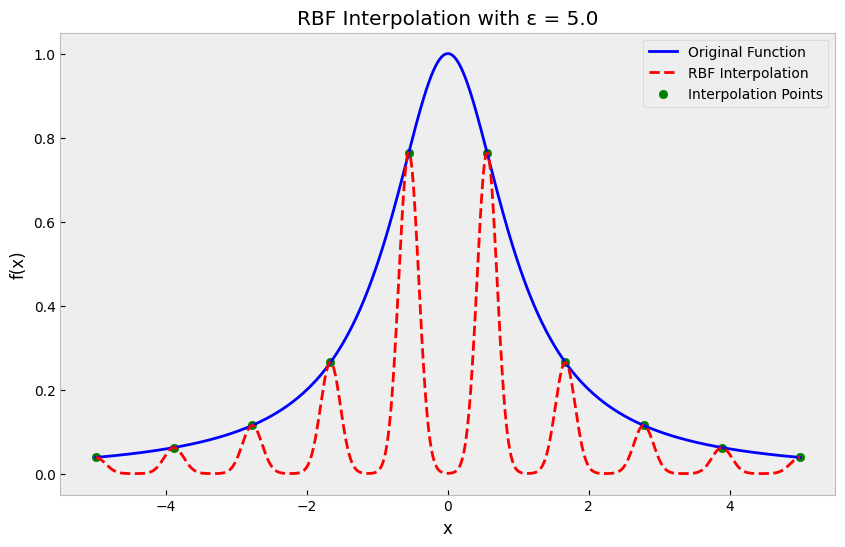

In [13]:
for epsilon in np.linspace(0.01, 5, 10):
    test = RBF(-5,5,function='runge_function',num_points=10,epsilon=epsilon)
    test.plot()

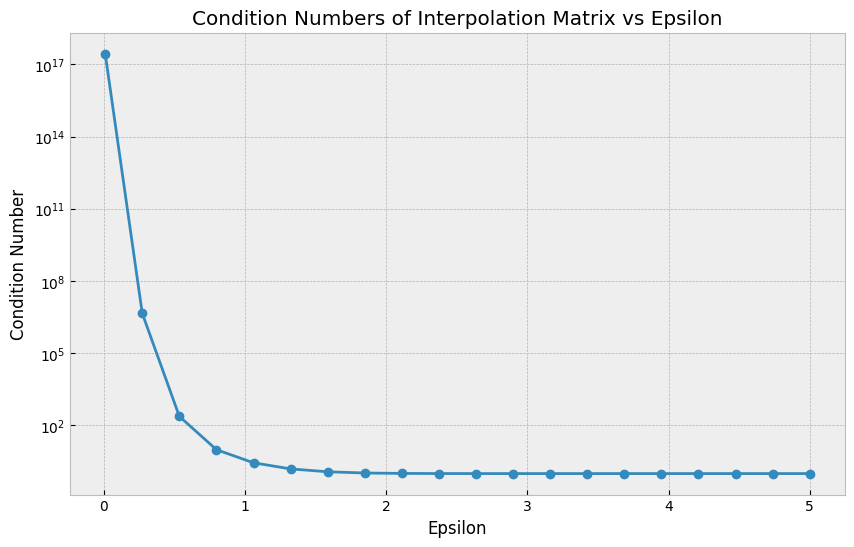

In [14]:
def plot_rbf_interpolation_condition_numbers(start, end, function='runge_function', num_points=10, epsilon_values=np.linspace(0.01, 5, 40)):
    """
    Plot the condition numbers of the interpolation matrix for different values of epsilon.

    Parameters:
    start (float): The starting point of the interval.
    end (float): The ending point of the interval.
    num_points (int): The number of interpolation points.
    epsilon_values (array-like): An array of epsilon values to evaluate.
    """
    condition_numbers = []

    for epsilon in epsilon_values:
        rbf = RBF(start, end, function=function, num_points=num_points, epsilon=epsilon)
        x = rbf.x_interpolate
        distance_matrix = np.abs(x[:, np.newaxis] - x[np.newaxis, :])
        M = rbf.phi(distance_matrix)
        cond_number = np.linalg.cond(M)
        condition_numbers.append(cond_number)

    plt.figure(figsize=(10, 6))
    plt.plot(epsilon_values, condition_numbers, marker='o')
    plt.title('Condition Numbers of Interpolation Matrix vs Epsilon')
    plt.xlabel('Epsilon')
    plt.ylabel('Condition Number')
    plt.yscale('log')

    plt.grid(True)
    plt.show()

plot_rbf_interpolation_condition_numbers(-5, 5, function='runge_function', num_points=10, epsilon_values=np.linspace(0.01, 5, 20))